# EEG Preprocessing: Real Data to Analysis-Ready Data

## Overview
This notebook preprocesses the real EEG recording used in the other notebook.

Pipeline:
1. Load real EDF data and prepare continuous channel matrix
2. Continuous filtering (high-pass and notch)
3. Epoching with buffer zones for frequency analyses
4. Common average re-referencing (CAR)
5. Bad-channel interpolation
6. Verification plots and quantitative checks

Goal: attenuate noise while preserving neural signal (signal-to-noise trade-off).

## Step 1: Load Real EEG Data

We load the EDF file from the project data folder and convert it to a channels-by-samples NumPy matrix in microvolts.

Notes:
- Channels `25+`, `26+`, `27+` are dropped to match the cleaning done in the other notebook.
- This notebook uses the real recording as the continuous input to preprocessing.

Extracting EDF parameters from ../data/sub-NORB00055_ses-1_task-EEG_eeg.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 227999  =      0.000 ...  1139.995 secs...
Loaded Real EEG Data:
  File: ../data/sub-NORB00055_ses-1_task-EEG_eeg.edf
  Channels after drop: 21
  Sampling Rate: 200 Hz
  Duration: 1140.00 s
  Total Samples: 228000
  Dropped channels: ['25+', '26+', '27+']

Raw Data Statistics (before filtering):
  Mean voltage: 6.6077 uV
  RMS voltage: 37.8612 uV
  Min voltage: -229.7500 uV
  Max voltage: 244.1000 uV



/tmp/ipykernel_35940/1516357773.py:11: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True)
/tmp/ipykernel_35940/1516357773.py:11: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True)
/tmp/ipykernel_35940/1516357773.py:11: RuntimeWarning: Highpass cutoff frequency 100.0 is greater than lowpass cutoff frequency 30.0, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(edf_path, preload=True)


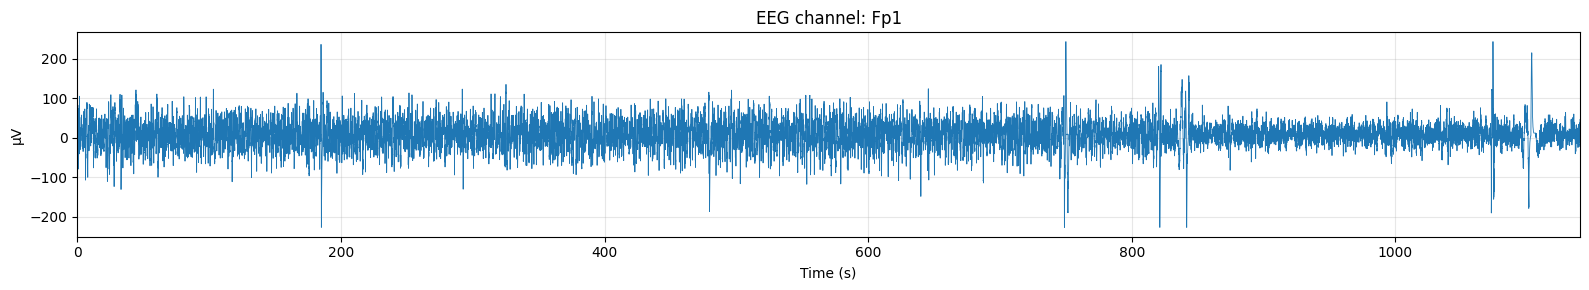

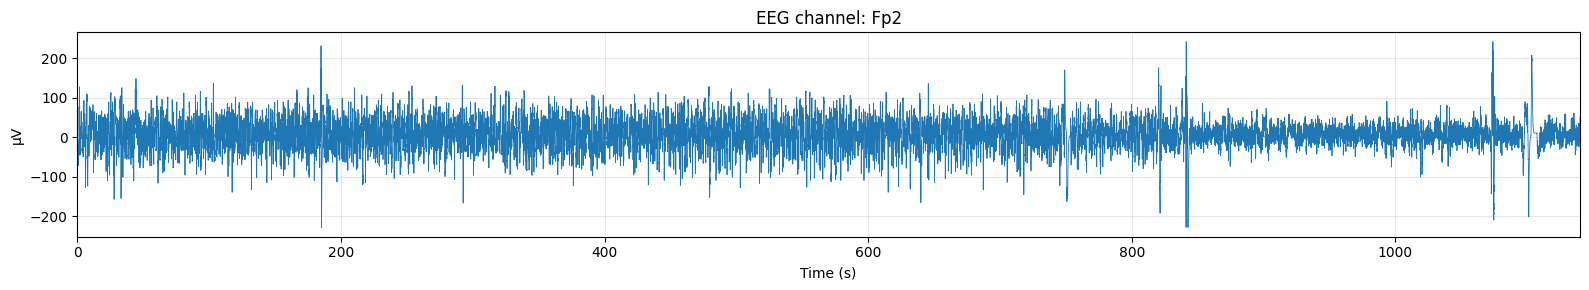

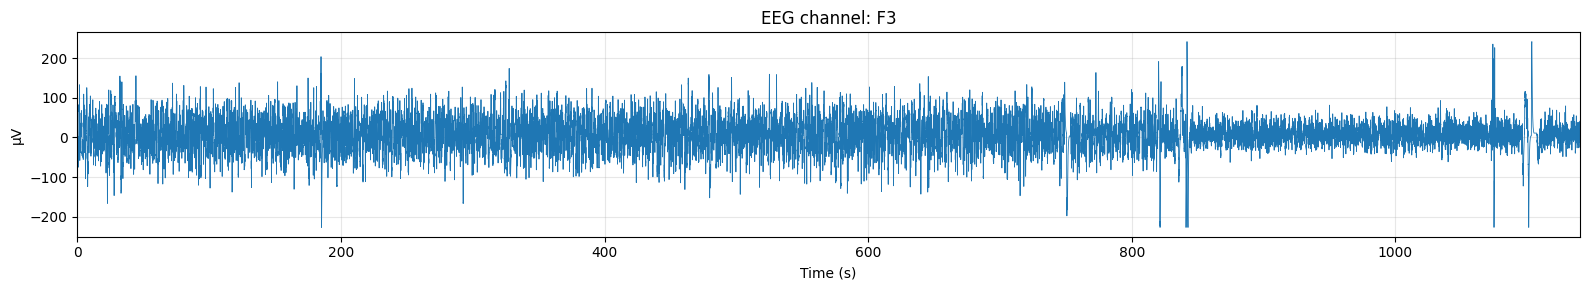

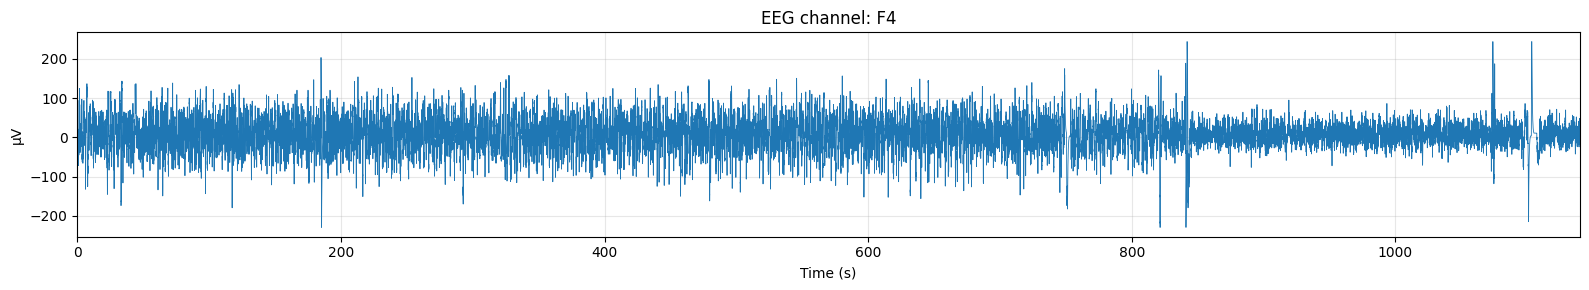

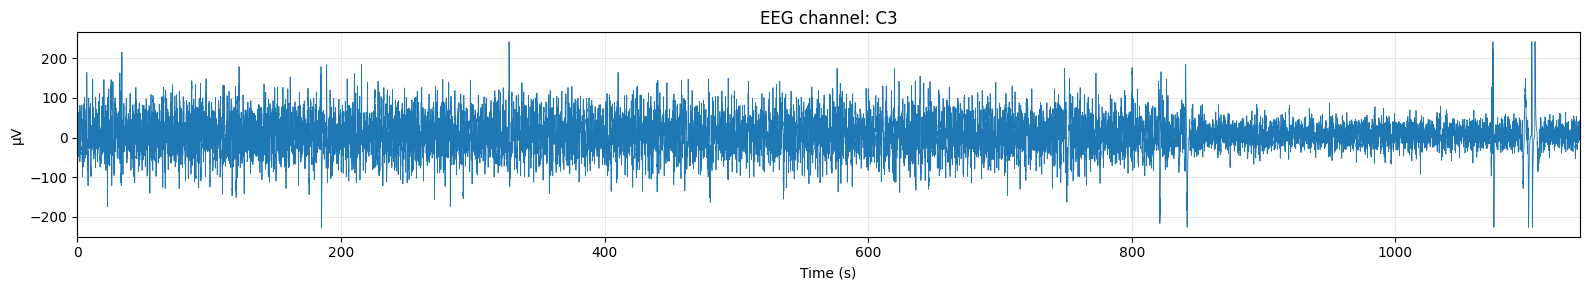

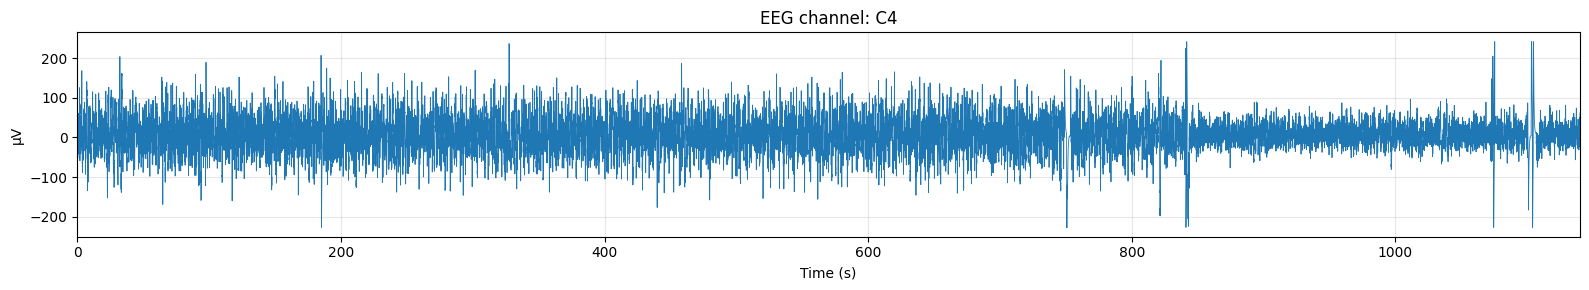

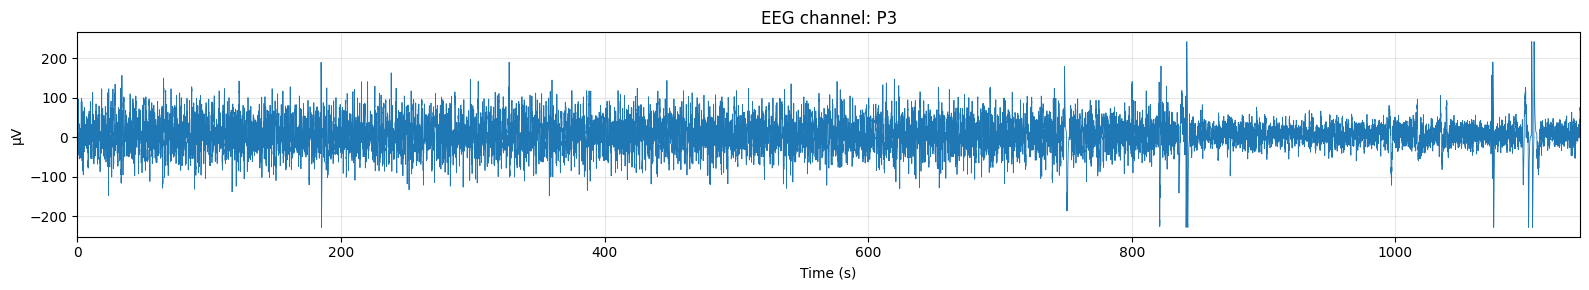

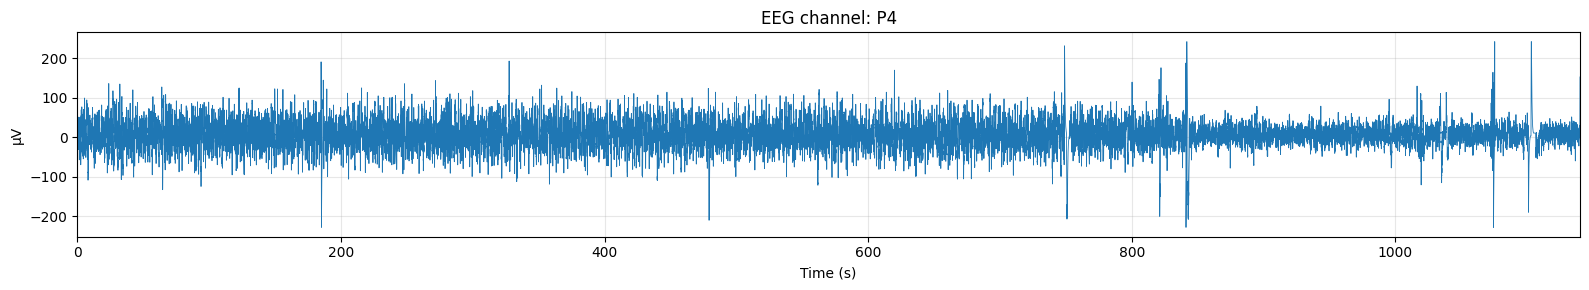

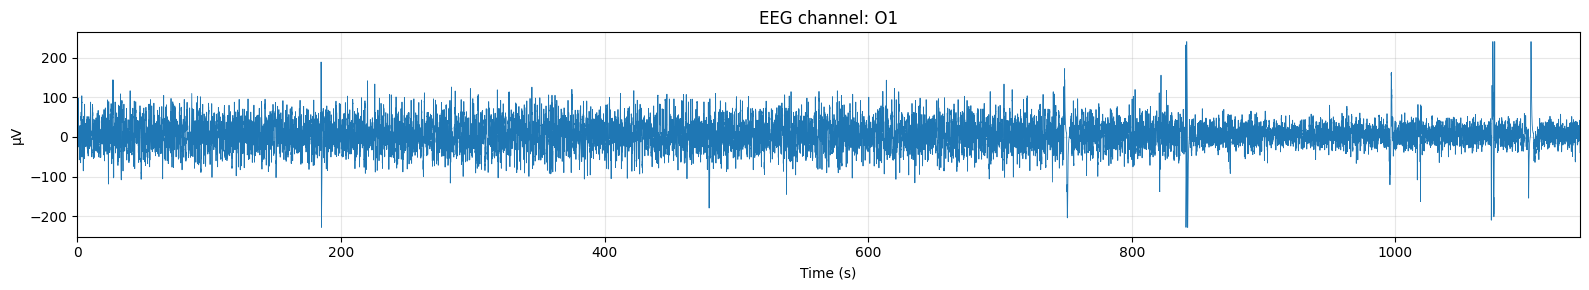

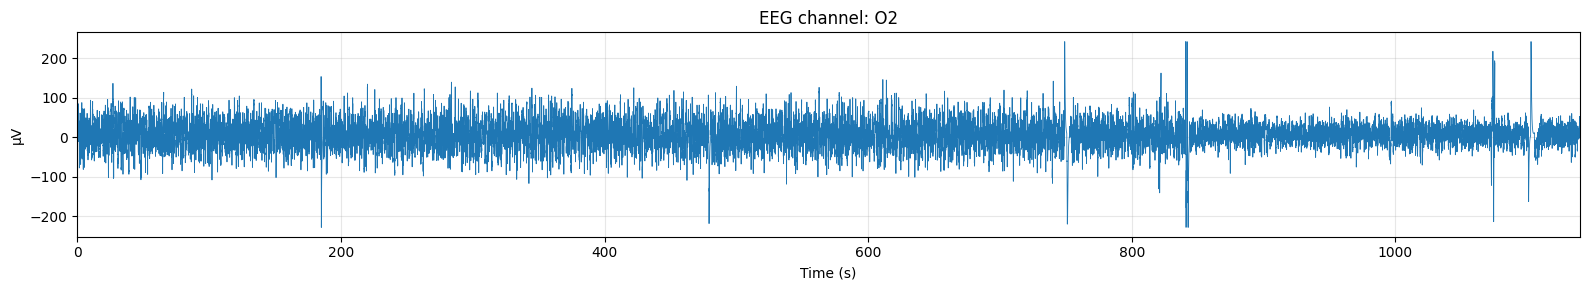

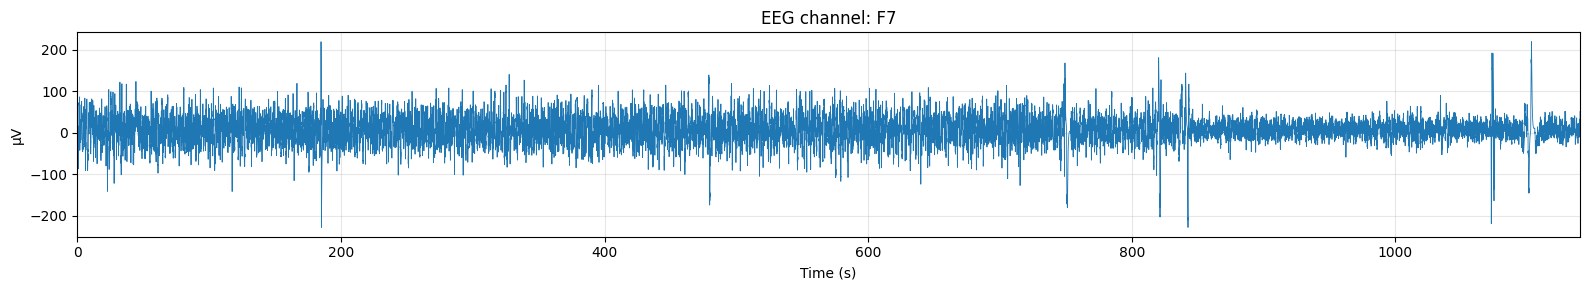

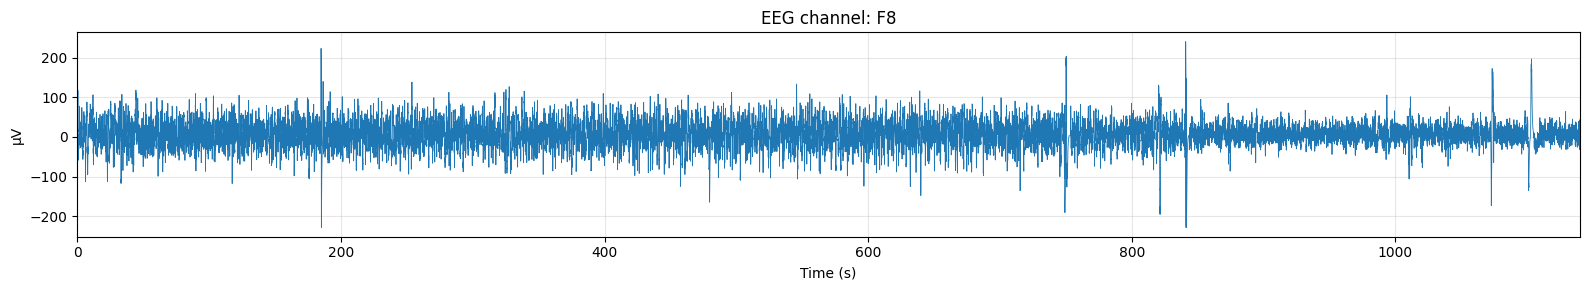

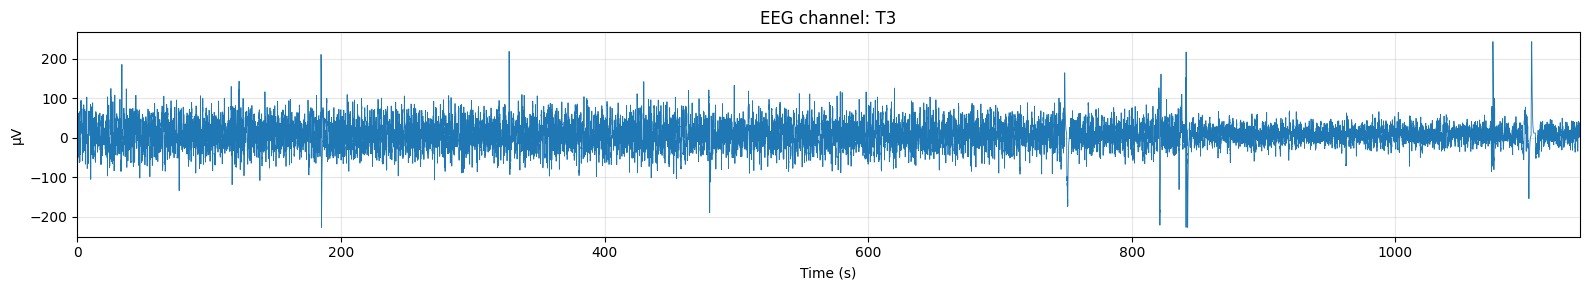

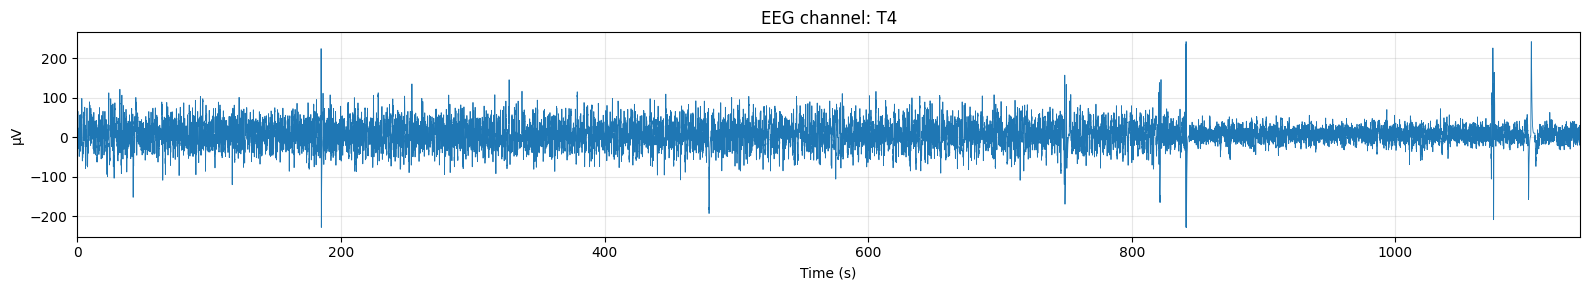

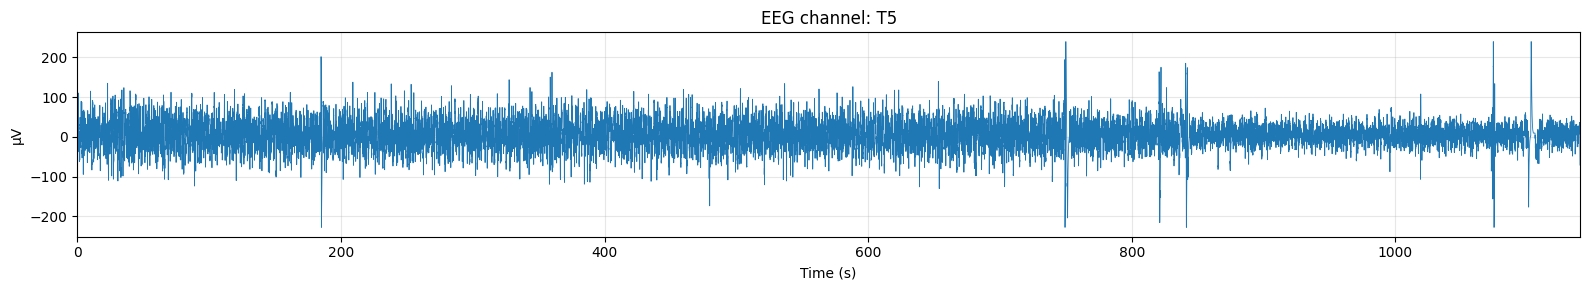

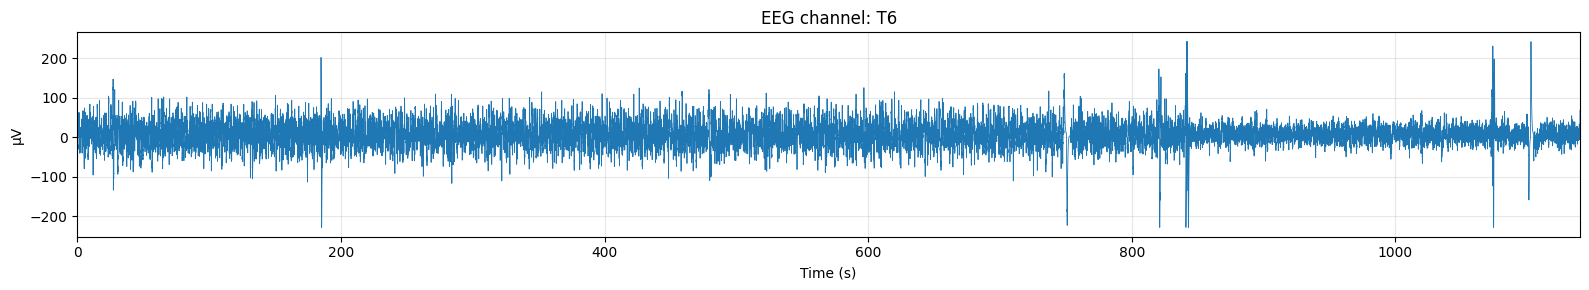

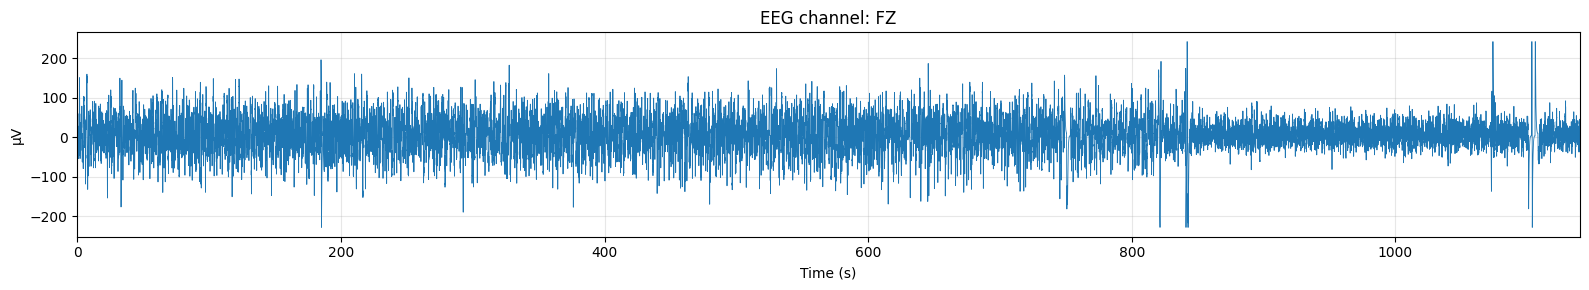

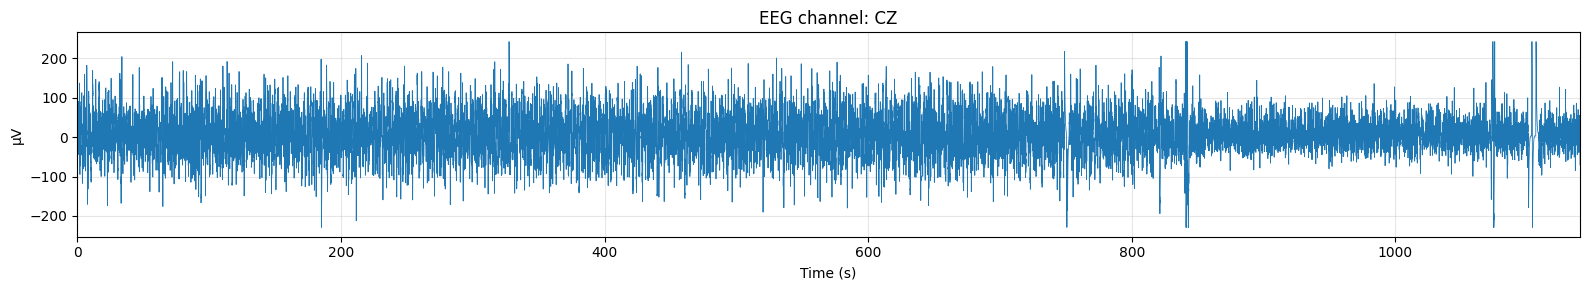

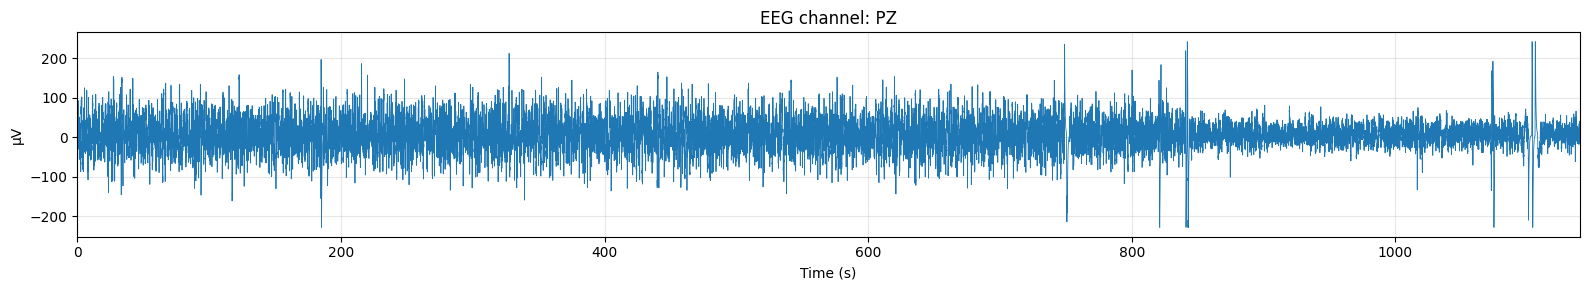

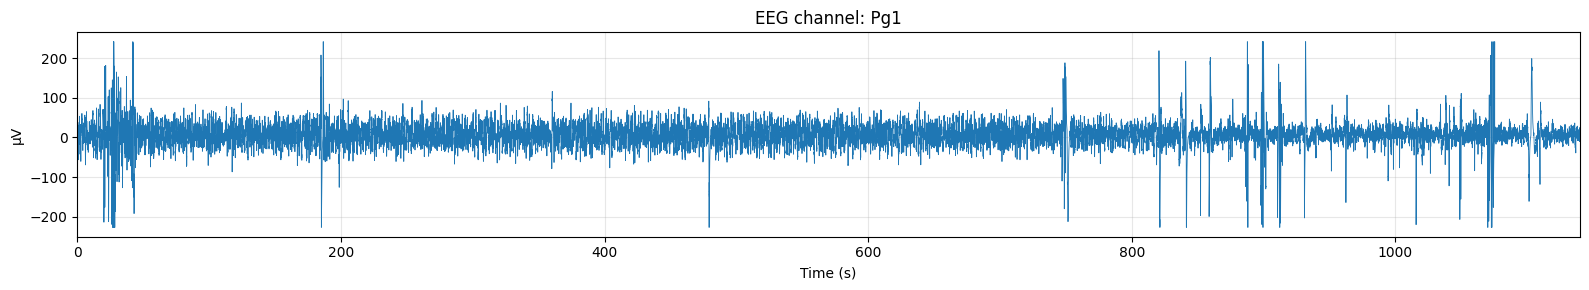

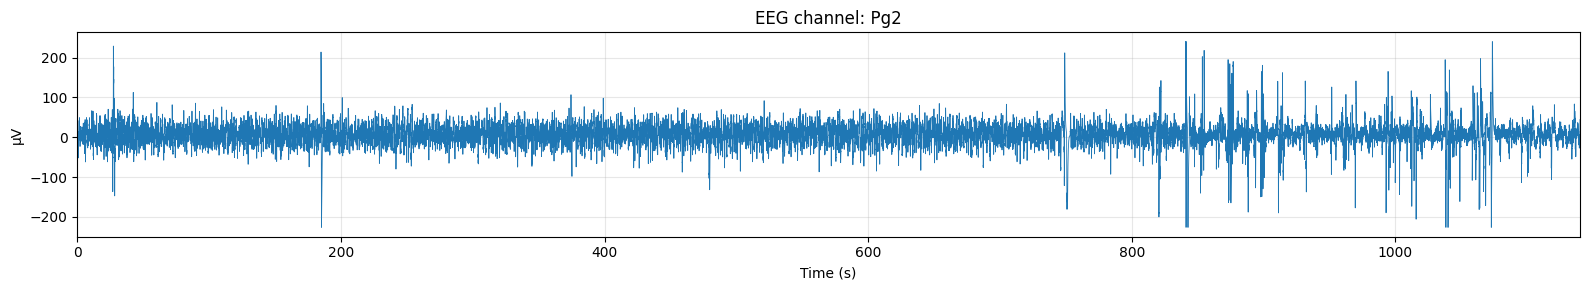

In [16]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# ============================================================================
# STEP 1: LOAD REAL EEG DATA
# ============================================================================

edf_path = "../data/sub-NORB00055_ses-1_task-EEG_eeg.edf"
raw = mne.io.read_raw_edf(edf_path, preload=True)

# Match channel cleanup used in test.ipynb
to_drop = [ch for ch in ["25+", "26+", "27+"] if ch in raw.ch_names]
if to_drop:
    raw.drop_channels(to_drop)

# Continuous data matrix: channels x samples, converted from V to uV
raw_data = raw.get_data() * 1e6
t = raw.times

n_channels, n_samples = raw_data.shape
sampling_rate = int(round(raw.info["sfreq"]))
duration = n_samples / sampling_rate

print("Loaded Real EEG Data:")
print(f"  File: {edf_path}")
print(f"  Channels after drop: {n_channels}")
print(f"  Sampling Rate: {sampling_rate} Hz")
print(f"  Duration: {duration:.2f} s")
print(f"  Total Samples: {n_samples}")
print(f"  Dropped channels: {to_drop}")
print()

print("Raw Data Statistics (before filtering):")
print(f"  Mean voltage: {np.mean(raw_data):.4f} uV")
print(f"  RMS voltage: {np.sqrt(np.mean(raw_data**2)):.4f} uV")
print(f"  Min voltage: {np.min(raw_data):.4f} uV")
print(f"  Max voltage: {np.max(raw_data):.4f} uV")
print()

data = raw.get_data() * 1e6  # convert V -> µV for readability
times = raw.times

# Create one static subplot per channel (full recording: 0 -> end)
n_ch = len(raw.ch_names)
fig, axes = plt.subplots(n_ch, 1, figsize=(16, max(2 * n_ch, 10)), sharex=True)

if n_ch == 1:
    axes = [axes]

# Close the previously created big canvas
plt.close(fig)

# Plot each channel in its own independent figure
for i, ch_name in enumerate(raw.ch_names):
    fig_ch, ax = plt.subplots(figsize=(16, 3))
    ax.plot(times, data[i], linewidth=0.6)
    ax.set_title(f"EEG channel: {ch_name}")
    ax.set_ylabel("µV")
    ax.set_xlabel("Time (s)")
    ax.grid(alpha=0.3)
    ax.set_xlim(0, times[-1])
    plt.tight_layout()
    plt.show()

## Step 2: Continuous Filtering (Before Epoching)

**Why filter BEFORE epoching?**
- High-pass and notch filters produce **edge artifacts** at sharp temporal boundaries
- These artifacts can extend 3-6 seconds into the data
- If you filter after epoching short trials, the artifacts contaminate the entire epoch
- Solution: Filter continuous data, then epoch (edge artifacts fall in buffer zones)

**Filter Design:**
- **High-Pass (0.5 Hz)**: Remove DC offset and slow drift
- **Notch (60 Hz, 2 Hz width)**: Remove line noise precisely

In [17]:
# ============================================================================
# STEP 2: CONTINUOUS FILTERING
# ============================================================================

# Copy raw data for filtering (preserve original for comparison)
filtered_data = raw_data.copy()

# --- HIGH-PASS FILTER ---
# Design a high-pass Butterworth filter at 0.5 Hz
# Butterworth: Maximally flat frequency response (preferred for EEG)

highpass_freq = 0.5  # Hz (remove drift below this frequency)
filter_order = 4     # Order 4: -24 dB/octave roll-off (good balance of steepness vs. stability)

# Design the high-pass filter
# Normalize frequency to Nyquist frequency (sampling_rate/2)
nyquist = sampling_rate / 2
highpass_normalized = highpass_freq / nyquist

# Create Butterworth high-pass filter coefficients
b_highpass, a_highpass = signal.butter(filter_order, highpass_normalized, btype='high')

# Apply to all channels using filtfilt (zero-phase filtering)
# filtfilt: Apply filter forward and backward to eliminate phase distortion
print(f"Applying High-Pass Filter ({highpass_freq} Hz):")
for ch in range(n_channels):
    filtered_data[ch] = signal.filtfilt(b_highpass, a_highpass, filtered_data[ch])
    if ch == 0:
        print(f"  ✓ Channel {ch}: High-pass filtering complete")
print()

# --- NOTCH FILTER ---
# Design a notch (band-stop) filter at 60 Hz to remove line noise
# Notch is narrow, targeting only the problematic frequency

notch_freq = 60    # Hz (center frequency of line noise)
notch_width = 2    # Hz (Q-factor determines width of stopband)
Q = notch_freq / notch_width  # Quality factor (higher Q = narrower notch)

# Create notch filter using iirnotch
# iirnotch is optimized specifically for narrow stopband filtering
b_notch, a_notch = signal.iirnotch(notch_freq, Q, sampling_rate)

# Apply notch filter to all channels
print(f"Applying Notch Filter ({notch_freq} Hz ± {notch_width/2} Hz):")
for ch in range(n_channels):
    filtered_data[ch] = signal.filtfilt(b_notch, a_notch, filtered_data[ch])
    if ch == 0:
        print(f"  ✓ Channel {ch}: Notch filtering complete")
print()

# --- VERIFY FILTERING EFFECTIVENESS ---
print(f"Filtering Results:")
print(f"  Mean voltage (after filtering): {np.mean(filtered_data):.4f} µV")
print(f"  RMS reduction: {100*(1 - np.sqrt(np.mean(filtered_data**2))/np.sqrt(np.mean(raw_data**2))):.1f}%")
print(f"  (RMS before: {np.sqrt(np.mean(raw_data**2)):.4f} µV)")
print(f"  (RMS after: {np.sqrt(np.mean(filtered_data**2)):.4f} µV)")
print()

Applying High-Pass Filter (0.5 Hz):
  ✓ Channel 0: High-pass filtering complete

Applying Notch Filter (60 Hz ± 1.0 Hz):
  ✓ Channel 0: Notch filtering complete

Filtering Results:
  Mean voltage (after filtering): 0.0012 µV
  RMS reduction: 15.9%
  (RMS before: 37.8612 µV)
  (RMS after: 31.8578 µV)



In [18]:
# ============================================================================
# STEP 3: EPOCHING WITH BUFFER ZONES
# ============================================================================

# Define epoching parameters
trial_duration = 1100.0      # seconds (1-second trial: 0 to 1000 ms)
trial_samples = int(trial_duration * sampling_rate)

buffer_duration = 1.5     # seconds (1.5-second buffer for 3-cycle rule at 2 Hz)
buffer_samples = int(buffer_duration * sampling_rate)

total_epoch_samples = buffer_samples + trial_samples + buffer_samples

print("Epoching Parameters (3-Cycle Rule for 2 Hz minimum frequency):")
print(f"  Trial duration: {trial_duration} s ({trial_samples} samples)")
print(f"  Buffer duration: {buffer_duration} s ({buffer_samples} samples, 3/2 = 1.5 s)")
print(f"  Total epoch: {total_epoch_samples/sampling_rate:.1f} s ({total_epoch_samples} samples)")
print()

# Find valid trial starts that keep full buffers inside recording
min_start = buffer_samples
max_start = n_samples - (trial_samples + buffer_samples)

if max_start <= min_start:
    raise ValueError(
        "Recording is too short for 1 s trials with 1.5 s buffers on both sides."
    )

# Use up to 5 evenly-spaced trials depending on recording length
max_trials_possible = max(1, (max_start - min_start) // trial_samples + 1)
n_trials = min(5, max_trials_possible)
trial_starts = np.linspace(min_start, max_start, n_trials, dtype=int)

epochs_with_buffer = np.zeros((n_trials, n_channels, total_epoch_samples))
epochs = np.zeros((n_trials, n_channels, trial_samples))

print(f"Extracting {n_trials} epochs with buffers:")
for trial_idx, trial_start in enumerate(trial_starts):
    epoch_start = trial_start - buffer_samples
    epoch_end = trial_start + trial_samples + buffer_samples
    epochs_with_buffer[trial_idx] = filtered_data[:, epoch_start:epoch_end]

    trial_start_in_epoch = buffer_samples
    trial_end_in_epoch = buffer_samples + trial_samples
    epochs[trial_idx] = epochs_with_buffer[
        trial_idx, :, trial_start_in_epoch:trial_end_in_epoch
    ]

    print(
        f"  Trial {trial_idx+1}: Sample {epoch_start:6d}-{epoch_end:6d} "
        f"(buffer: {epoch_start}-{trial_start}, "
        f"trial: {trial_start}-{trial_start+trial_samples})"
    )

print()
print("Epoch Array Dimensions:")
print(f"  epochs_with_buffer: {epochs_with_buffer.shape} (trials x channels x samples)")
print(f"  epochs: {epochs.shape} (trials x channels x samples)")
print()

Epoching Parameters (3-Cycle Rule for 2 Hz minimum frequency):
  Trial duration: 1100.0 s (220000 samples)
  Buffer duration: 1.5 s (300 samples, 3/2 = 1.5 s)
  Total epoch: 1103.0 s (220600 samples)

Extracting 1 epochs with buffers:
  Trial 1: Sample      0-220600 (buffer: 0-300, trial: 300-220300)

Epoch Array Dimensions:
  epochs_with_buffer: (1, 21, 220600) (trials x channels x samples)
  epochs: (1, 21, 220000) (trials x channels x samples)



## Step 4: Re-referencing to Common Average Reference (CAR)

**Why re-reference?**
- EEG measures voltage *relative* to a reference electrode
- Different references can emphasize different parts of the brain

**Common Average Reference (CAR):**
- Average voltage across all channels: `CAR[t] = mean(all_channels[t])`
- Subtract this global average from each channel
- Eliminates common-mode noise (affects all channels equally)
- Prerequisite: Must have a good coverage of electrodes across the scalp
- **Warning:** Don't include bad/noisy channels in the average!

In [19]:
# ============================================================================
# STEP 4: RE-REFERENCING TO COMMON AVERAGE REFERENCE (CAR)
# ============================================================================

print(f"Re-referencing to Common Average Reference (CAR):")
print()

# Initialize re-referenced epochs
epochs_rereferenced = epochs.copy()

# For each trial, compute the average across all channels at each time point
# then subtract from each channel

for trial_idx in range(n_trials):
    # Compute average reference signal across all channels
    # Shape: (trial_samples,) - one value per time point
    car_signal = np.mean(epochs[trial_idx], axis=0)
    
    # Subtract common average from each channel
    for ch in range(n_channels):
        epochs_rereferenced[trial_idx, ch, :] = epochs[trial_idx, ch, :] - car_signal

print(f"  ✓ All {n_trials} trials re-referenced to CAR")
print()

# Verify re-referencing
print(f"Verification (Trial 1):")
print(f"  Mean voltage before CAR: {np.mean(epochs[0]):.4f} µV")
print(f"  Mean voltage after CAR: {np.mean(epochs_rereferenced[0]):.4f} µV")
print(f"  ✓ Global mean reduced to near-zero (expected due to averaging)")
print()

# Additional check: Mean voltage per channel should be closer to zero
mean_before_car = np.mean(np.mean(epochs, axis=2), axis=0)  # Mean per channel before CAR
mean_after_car = np.mean(np.mean(epochs_rereferenced, axis=2), axis=0)  # Mean per channel after CAR

print(f"Per-channel mean comparison (across all trials):")
print(f"  Before CAR: RMS of channel means = {np.sqrt(np.mean(mean_before_car**2)):.4f} µV")
print(f"  After CAR:  RMS of channel means = {np.sqrt(np.mean(mean_after_car**2)):.6f} µV")
print(f"  ✓ CAR successfully removes global offset")
print()

Re-referencing to Common Average Reference (CAR):

  ✓ All 1 trials re-referenced to CAR

Verification (Trial 1):
  Mean voltage before CAR: -0.0035 µV
  Mean voltage after CAR: -0.0000 µV
  ✓ Global mean reduced to near-zero (expected due to averaging)

Per-channel mean comparison (across all trials):
  Before CAR: RMS of channel means = 0.0055 µV
  After CAR:  RMS of channel means = 0.004203 µV
  ✓ CAR successfully removes global offset



## Step 6: Verification - Before and After Comparisons

We now visualize the effectiveness of preprocessing by comparing:
1. **Power Spectrum**: 60 Hz line noise removal verification
2. **DC Offset**: High-pass filter effectiveness
3. **Channel Quality**: Good vs. interpolated channels
4. **Signal Evolution**: Raw → Filtered → Epoched → Preprocessed

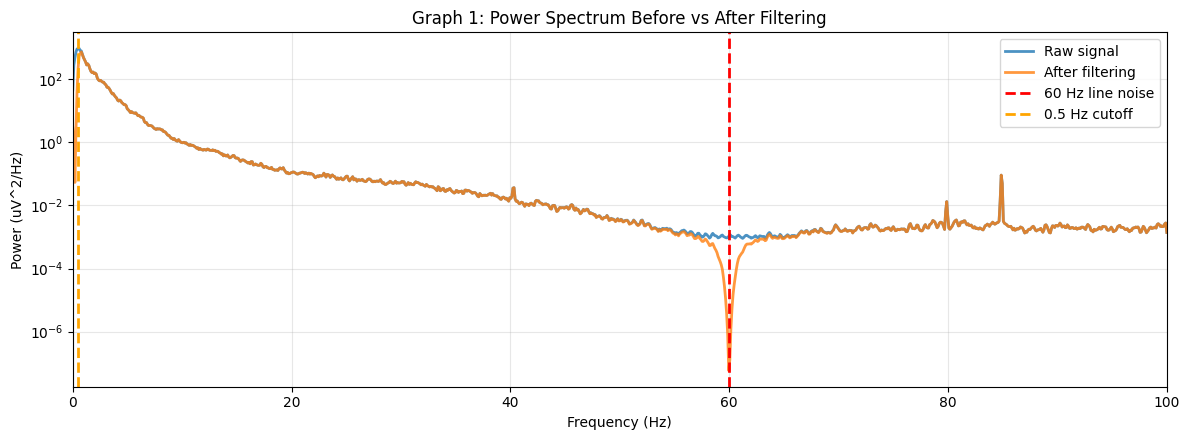

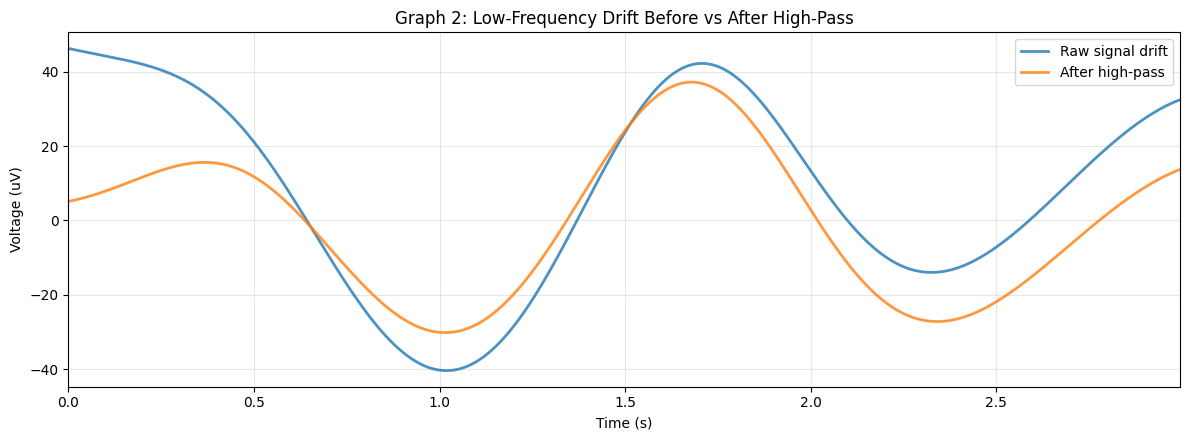

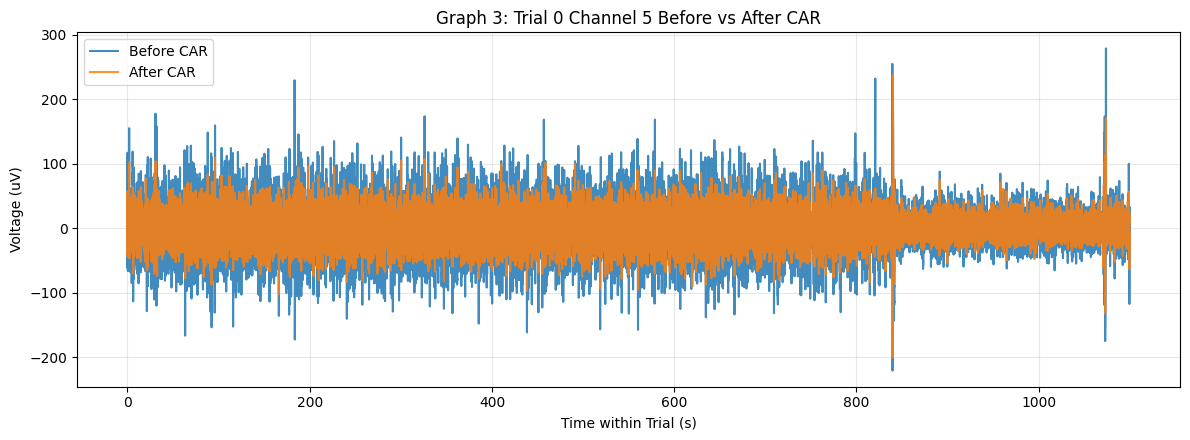

Rendered 3 separate verification graphs.


In [20]:
# ============================================================================
# STEP 6: VERIFICATION AND VISUALIZATION
# ============================================================================

# Graph 1: Power spectrum before/after filtering
fig1, ax1 = plt.subplots(figsize=(12, 4.5))
nperseg = min(2048, n_samples)
freqs_raw, pxx_raw = signal.welch(raw_data[0], fs=sampling_rate, nperseg=nperseg)
freqs_filt, pxx_filt = signal.welch(filtered_data[0], fs=sampling_rate, nperseg=nperseg)
ax1.semilogy(freqs_raw, pxx_raw, label="Raw signal", linewidth=2, alpha=0.8)
ax1.semilogy(freqs_filt, pxx_filt, label="After filtering", linewidth=2, alpha=0.8)
ax1.axvline(60, color="red", linestyle="--", linewidth=2, label="60 Hz line noise")
ax1.axvline(0.5, color="orange", linestyle="--", linewidth=2, label="0.5 Hz cutoff")
ax1.set_xlabel("Frequency (Hz)")
ax1.set_ylabel("Power (uV^2/Hz)")
ax1.set_title("Graph 1: Power Spectrum Before vs After Filtering")
ax1.grid(alpha=0.3)
ax1.legend(loc="best")
ax1.set_xlim(0, 100)
plt.tight_layout()
plt.show()

# Graph 2: Low-frequency drift before/after high-pass
fig2, ax2 = plt.subplots(figsize=(12, 4.5))
b_lowpass, a_lowpass = signal.butter(4, 1 / nyquist, btype="low")
drift_raw_ch0 = signal.filtfilt(b_lowpass, a_lowpass, raw_data[0])
drift_filt_ch0 = signal.filtfilt(b_lowpass, a_lowpass, filtered_data[0])
trend_samples = min(3 * sampling_rate, len(t))
trend_time = t[:trend_samples]
ax2.plot(
    trend_time,
    drift_raw_ch0[:trend_samples],
    label="Raw signal drift",
    linewidth=2,
    alpha=0.8,
)
ax2.plot(
    trend_time,
    drift_filt_ch0[:trend_samples],
    label="After high-pass",
    linewidth=2,
    alpha=0.8,
)
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Voltage (uV)")
ax2.set_title("Graph 2: Low-Frequency Drift Before vs After High-Pass")
ax2.grid(alpha=0.3)
ax2.legend(loc="best")
ax2.set_xlim(0, trend_time[-1])
plt.tight_layout()
plt.show()

# Graph 3: Trial segment before/after CAR
fig3, ax3 = plt.subplots(figsize=(12, 4.5))
trial_idx = 0
channel_idx = 5 if n_channels > 5 else 0
trial_time = np.arange(trial_samples) / sampling_rate
ax3.plot(
    trial_time,
    epochs[trial_idx, channel_idx, :],
    label="Before CAR",
    linewidth=1.5,
    alpha=0.85,
)
ax3.plot(
    trial_time,
    epochs_rereferenced[trial_idx, channel_idx, :],
    label="After CAR",
    linewidth=1.5,
    alpha=0.85,
)
ax3.set_xlabel("Time within Trial (s)")
ax3.set_ylabel("Voltage (uV)")
ax3.set_title(f"Graph 3: Trial {trial_idx} Channel {channel_idx} Before vs After CAR")
ax3.grid(alpha=0.3)
ax3.legend(loc="best")
plt.tight_layout()
plt.show()

print("Rendered 3 separate verification graphs.")

## Summary: Preprocessing Pipeline Results

The complete EEG preprocessing pipeline achieves:

In [22]:
# ============================================================================
# PREPROCESSING SUMMARY
# ============================================================================

print("=" * 80)
print("EEG PREPROCESSING PIPELINE: SUMMARY OF RESULTS")
print("=" * 80)
print()

print("STEP 1: REAL DATA LOADING")
print("-" * 80)
print(f"  + Loaded EDF recording with {n_channels} channels at {sampling_rate} Hz")
print(f"  + Duration: {duration:.2f} s ({n_samples} samples)")
print(f"  + Dropped channels to match prior cleaning: {to_drop}")
print(f"  + Initial signal quality: RMS = {np.sqrt(np.mean(raw_data**2)):.2f} uV")
print()

print("STEP 2: CONTINUOUS FILTERING")
print("-" * 80)
print("  + High-pass filter (0.5 Hz): removes slow drift and baseline shifts")
print("    - Butterworth order 4")
print("    - Zero-phase application with filtfilt")
print(f"  + Notch filter (60 Hz, Q={Q:.1f}): suppresses line noise")
print("    - Narrow stopband around 60 Hz")
print(
    f"  + Result: RMS = {np.sqrt(np.mean(filtered_data**2)):.2f} uV "
    f"(reduction: {100*(1 - np.sqrt(np.mean(filtered_data**2))/np.sqrt(np.mean(raw_data**2))):.1f}%)"
)
print()

print("STEP 3: EPOCHING WITH BUFFERS")
print("-" * 80)
print(f"  + Extracted {n_trials} trials of {trial_duration} s each")
print(f"  + Added {buffer_duration} s buffers for 3-cycle rule at 2 Hz")
print(f"  + Total buffered epoch length: {total_epoch_samples/sampling_rate:.1f} s")
print("  + Buffer keeps boundary artifacts away from trial core")
print()

print("STEP 4: RE-REFERENCING")
print("-" * 80)
print(f"  + Applied Common Average Reference (CAR) to all {n_trials} trials")
print("  + Reduced global/common-mode activity")
print(
    f"  + Per-channel mean RMS: {np.sqrt(np.mean(mean_before_car**2)):.4f} -> "
    f"{np.sqrt(np.mean(mean_after_car**2)):.6f} uV"
)
print()
print("FINAL OUTPUT")
print("-" * 80)
print(f"  Data shape: {epochs_rereferenced.shape}")
print(f"    - Trials: {n_trials}")
print(f"    - Channels: {n_channels}")
print(f"    - Samples/Trial: {trial_samples} ({trial_duration} s at {sampling_rate} Hz)")
print("  + Ready for frequency-domain and time-domain analysis")
print()

print("KEY PRINCIPLES APPLIED")
print("-" * 80)
print("  + Filter continuous data before epoching")
print("  + Use buffer zones for low-frequency analyses")
print("  + Re-reference after cleaning")
print("  + Interpolate bad channels before spatial operations")
print()

print("=" * 80)

EEG PREPROCESSING PIPELINE: SUMMARY OF RESULTS

STEP 1: REAL DATA LOADING
--------------------------------------------------------------------------------
  + Loaded EDF recording with 21 channels at 200 Hz
  + Duration: 1140.00 s (228000 samples)
  + Dropped channels to match prior cleaning: ['25+', '26+', '27+']
  + Initial signal quality: RMS = 37.86 uV

STEP 2: CONTINUOUS FILTERING
--------------------------------------------------------------------------------
  + High-pass filter (0.5 Hz): removes slow drift and baseline shifts
    - Butterworth order 4
    - Zero-phase application with filtfilt
  + Notch filter (60 Hz, Q=30.0): suppresses line noise
    - Narrow stopband around 60 Hz
  + Result: RMS = 31.86 uV (reduction: 15.9%)

STEP 3: EPOCHING WITH BUFFERS
--------------------------------------------------------------------------------
  + Extracted 1 trials of 1100.0 s each
  + Added 1.5 s buffers for 3-cycle rule at 2 Hz
  + Total buffered epoch length: 1103.0 s
  + Buffer 

## Step 7: Export Preprocessed Data

This step saves analysis-ready outputs to disk so downstream notebooks/scripts can load the same preprocessed data without rerunning the full pipeline.

Exports:
- `epochs_rereferenced.npy`: final preprocessed epochs (trials x channels x samples)
- `epochs.npy`: epoched data before CAR (trials x channels x samples)
- `epochs_with_buffer.npy`: buffered epochs (trials x channels x samples)
- `preprocessing_metadata.npz`: key parameters and channel metadata

In [ ]:
# ============================================================================
# STEP 7: EXPORT PREPROCESSED DATA
# ============================================================================

from pathlib import Path

export_dir = Path("../data/preprocessed")
export_dir.mkdir(parents=True, exist_ok=True)

# Save core arrays as .npy for fast and lossless reload
epochs_rereferenced_path = export_dir / "epochs_rereferenced.npy"
epochs_path = export_dir / "epochs.npy"
epochs_with_buffer_path = export_dir / "epochs_with_buffer.npy"

np.save(epochs_rereferenced_path, epochs_rereferenced)
np.save(epochs_path, epochs)
np.save(epochs_with_buffer_path, epochs_with_buffer)

# Save lightweight metadata needed for reuse and validation
metadata_path = export_dir / "preprocessing_metadata.npz"
np.savez(
    metadata_path,
    sampling_rate=sampling_rate,
    trial_duration=trial_duration,
    trial_samples=trial_samples,
    buffer_duration=buffer_duration,
    buffer_samples=buffer_samples,
    n_trials=n_trials,
    n_channels=n_channels,
    dropped_channels=np.array(to_drop, dtype=object),
    channel_names=np.array(raw.ch_names, dtype=object),
)

print("Export complete:")
print(f"  - {epochs_rereferenced_path}")
print(f"  - {epochs_path}")
print(f"  - {epochs_with_buffer_path}")
print(f"  - {metadata_path}")
print()
print("Quick reload example:")
print("  data = np.load('../data/preprocessed/epochs_rereferenced.npy')")
print("  meta = np.load('../data/preprocessed/preprocessing_metadata.npz', allow_pickle=True)")